In [2]:
import pandas as pd
import numpy as np

df = pd.read_parquet("../data/data.parquet")

print(df.shape)
df.head()

(780126, 101)


,date,ticker,price,beta_1y,alpha_1y,sector,log_market_cap,pe,future_ret_1d,future_ret_1w,...,drawdown_rel_1y,drawdown_rel_5y,excess_vs_market_1y,trend_vs_market_1y,risk_adjusted_1y,risk_adjusted_5y,sector_is_strong,sector_is_trending,sector_high_breadth,quality_score
0,2016-06-29,FXY,94.019997,-0.627880,0.005701,Unknown,19.076858,NaN,-0.004680,0.020634,...,0.112084,0.015267,0.199827,0.000880,0.992065,-0.507272,False,False,False,3
1,2016-07-07,FXY,95.959999,-0.620811,0.005659,Unknown,19.097282,NaN,0.003126,-0.043664,...,0.121103,0.028355,0.171848,0.000870,0.822662,-0.501267,False,False,False,3
2,2016-07-14,FXY,91.769997,-0.615202,-0.008214,Unknown,19.052636,NaN,-0.001634,-0.003705,...,0.069193,-0.006695,0.134153,0.000822,0.619446,-0.572984,True,False,True,3
3,2016-07-21,FXY,91.430000,-0.617343,0.012402,Unknown,19.048924,NaN,-0.004375,0.002953,...,0.060752,-0.014856,0.098755,0.000759,0.485869,-0.616727,True,False,False,3
4,2016-07-28,FXY,91.699997,-0.619016,-0.000872,Unknown,19.051873,NaN,0.032824,0.041767,...,0.066455,-0.010704,0.093181,0.000702,0.525985,-0.630273,True,False,False,3


In [17]:
# Missing Data
missing = pd.DataFrame({
    "Missing": df.isna().sum(),
    "Percent": df.isna().mean() * 100
})

missing = missing[missing["Missing"] > 0]
print( missing.sort_values("Percent", ascending=False) )

missing_mc = df[df["log_market_cap"].isna()]

miss = df[df["log_market_cap"].isna()]["ticker"].nunique()
total = df["ticker"].nunique()
print(f"\nMissing market cap tickers: {miss}/{total} ({miss/total:.2%})")

missing_tickers = missing_mc["ticker"].unique()

print(
    df[df["ticker"].isin(missing_tickers)][["ticker","sector"]]
    .drop_duplicates()
)

                Missing    Percent
pe               185393  23.764494
log_market_cap    23016   2.950293

Missing market cap tickers: 93/3191 (2.91%)
       ticker              sector
471     FNMAP  Financial Services
1722     SVXY             Unknown
4972     SOYB             Unknown
14136    GORO             Unknown
18659     FXB             Unknown
...       ...                 ...
696499    DDT             Unknown
734760    PYT             Unknown
749902    YCL             Unknown
778861   GSCE             Unknown
779367    JBK             Unknown

[93 rows x 2 columns]


In [4]:
# Blank Data
string_cols = df.select_dtypes(include=["object", "string"]).columns
blank_found = 0

for col in string_cols:
    blanks = (df[col].astype(str).str.strip() == "").sum()
    if blanks:
        print(f"{col}: {blanks:,} blank values")
        blank_found += 1

print( f"{blank_found} blanks found.")

0 blanks found.


In [5]:
#Infinite data

numeric = df.select_dtypes(include=np.number)

inf = pd.DataFrame({
    "Positive Inf": np.isposinf(numeric).sum(),
    "Negative Inf": np.isneginf(numeric).sum()
})

inf = inf[(inf["Positive Inf"] > 0) | (inf["Negative Inf"] > 0)]
inf

,Positive Inf,Negative Inf


In [6]:
# Summary stats
numeric.describe().T

,count,mean,std,min,25%,50%,75%,max
price,780126.0,8.136001e+01,802.211338,1.000000,8.725001,20.471143,48.517547,4.992000e+04
beta_1y,780126.0,1.443704e+00,1.005172,-14.036741,0.762368,1.442836,2.048440,2.971985e+01
alpha_1y,780126.0,8.334634e-04,0.030896,-0.845324,-0.007896,0.000000,0.008229,5.382716e+00
log_market_cap,757110.0,2.117471e+01,2.198664,14.509317,19.509618,21.186442,22.775297,3.319599e+01
pe,594733.0,1.562170e+03,80555.961963,0.055336,5.163979,9.195257,17.948905,6.851351e+06
...,...,...,...,...,...,...,...,...
excess_vs_market_1y,780126.0,2.972868e-17,39.038268,-6.809245,-0.309866,-0.097924,0.088060,1.709308e+04
trend_vs_market_1y,780126.0,-1.120717e-20,0.001728,-0.018641,-0.000720,0.000047,0.000747,4.866664e-02
risk_adjusted_1y,780126.0,-4.563134e-18,0.998053,-5.771306,-0.432748,-0.100784,0.265694,2.890700e+01
risk_adjusted_5y,780126.0,-1.092966e-18,0.998053,-3.024118,-0.453973,-0.154322,0.200387,2.871225e+01


In [ ]:
# Checking highest priced stock
df.loc[df["price"].idxmax()]

date                   2017-02-09 00:00:00
ticker                                AEMD
price                              49920.0
beta_1y                           0.349119
alpha_1y                         -0.015201
                              ...         
risk_adjusted_5y                 -0.331536
sector_is_strong                      True
sector_is_trending                   False
sector_high_breadth                   True
quality_score                            0
Name: 258327, Length: 101, dtype: object

In [21]:
# Checking distribution of prices
df["price"].describe(percentiles=[0.01, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99, 0.999, 0.9999])

count     780126.000000
mean          81.360012
std          802.211338
min            1.000000
1%             1.310000
25%            8.725001
50%           20.471143
75%           48.517547
90%          101.468086
95%          166.699917
99%          688.999451
99.9%       8735.095947
99.99%     39000.000000
max        49920.000000
Name: price, dtype: float64

In [ ]:
# Looking at outliers

high_price = df[df["price"] > 1000]

print(high_price.shape)
print(high_price["ticker"].nunique())

high_price[["ticker","date","price"]].sort_values(
    "price",
    ascending=False
).head(54)

(5454, 101)
54


,ticker,date,price
258327,AEMD,2017-02-09,49920.000000
131763,UVXY,2020-08-17,49775.000000
30261,BGMS,2018-04-27,49704.824219
30259,BGMS,2018-03-22,49704.824219
285315,BOIL,2019-01-30,49520.000000
131764,UVXY,2020-08-24,49500.000000
30264,BGMS,2018-05-18,49357.238281
30262,BGMS,2018-05-04,49357.238281
30268,BGMS,2018-07-10,49009.652344
30265,BGMS,2018-06-04,49009.652344


In [7]:
# Largest

for col in numeric.columns:
    print(f"\n{col}")
    print(df.nlargest(5, col)[["ticker", "date", col]])
    print(df.nsmallest(5, col)[["ticker", "date", col]])


price
       ticker       date         price
258327   AEMD 2017-02-09  49920.000000
131763   UVXY 2020-08-17  49775.000000
30259    BGMS 2018-03-22  49704.824219
30261    BGMS 2018-04-27  49704.824219
285315   BOIL 2019-01-30  49520.000000
      ticker       date  price
10303   NLST 2017-02-24    1.0
62961   CAPR 2020-03-11    1.0
67431   ZNOG 2020-12-02    1.0
68431  OCGSF 2016-07-14    1.0
68433  OCGSF 2016-07-28    1.0

beta_1y
       ticker       date    beta_1y
297720   DTST 2021-07-01  29.719850
297719   DTST 2021-06-24  28.802884
297718   DTST 2021-06-17  28.226918
297717   DTST 2021-06-10  27.290823
297716   DTST 2021-06-03  20.357361
       ticker       date    beta_1y
728789   BEGI 2017-06-13 -14.036741
728787   BEGI 2017-05-15 -13.842402
326423   CHRD 2021-06-24 -13.488980
326424   CHRD 2021-07-01 -13.474812
728788   BEGI 2017-05-22 -13.466552

alpha_1y
       ticker       date  alpha_1y
385521   SCKT 2021-02-16  5.382716
349046   BMRA 2020-03-18  2.826549
103038   GEVO 201

In [8]:
# Outliers

outliers = []

for col in numeric.columns:
    q1 = numeric[col].quantile(0.25)
    q3 = numeric[col].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    count = ((numeric[col] < lower) | (numeric[col] > upper)).sum()

    outliers.append({
        "Column": col,
        "Outliers": count,
        "Percent": count / len(df) * 100
    })

pd.DataFrame(outliers).sort_values("Percent", ascending=False)

,Column,Outliers,Percent
65,sec_avg_ret_6m_market,148549,19.041668
89,excess_vs_market_1y,99910,12.806906
82,sec_ret_5y_dispersion_market,99746,12.785883
32,sector_Industrials,99667,12.775757
61,rows_market,96727,12.398895
...,...,...,...
37,sector_size,0,0.000000
38,rows,0,0.000000
69,sec_breadth_positive_1y_market,0,0.000000
80,sec_high_monotonic_pct_market,0,0.000000


In [9]:
# Impossible

checks = {
    "price <= 0": (df["price"] <= 0).sum(),
    "beta NaN": df["beta_1y"].isna().sum(),
    "alpha NaN": df["alpha_1y"].isna().sum(),
    "market cap NaN": df["log_market_cap"].isna().sum(),
    "PE <= 0": (df["pe"] <= 0).sum(),
    "1y drawdown > 0": (df["1y_drawdown"] > 0).sum(),
    "5y drawdown > 0": (df["5y_drawdown"] > 0).sum(),
}

pd.Series(checks)

price <= 0             0
beta NaN               0
alpha NaN              0
market cap NaN     23016
PE <= 0                0
1y drawdown > 0        0
5y drawdown > 0        0
dtype: int64

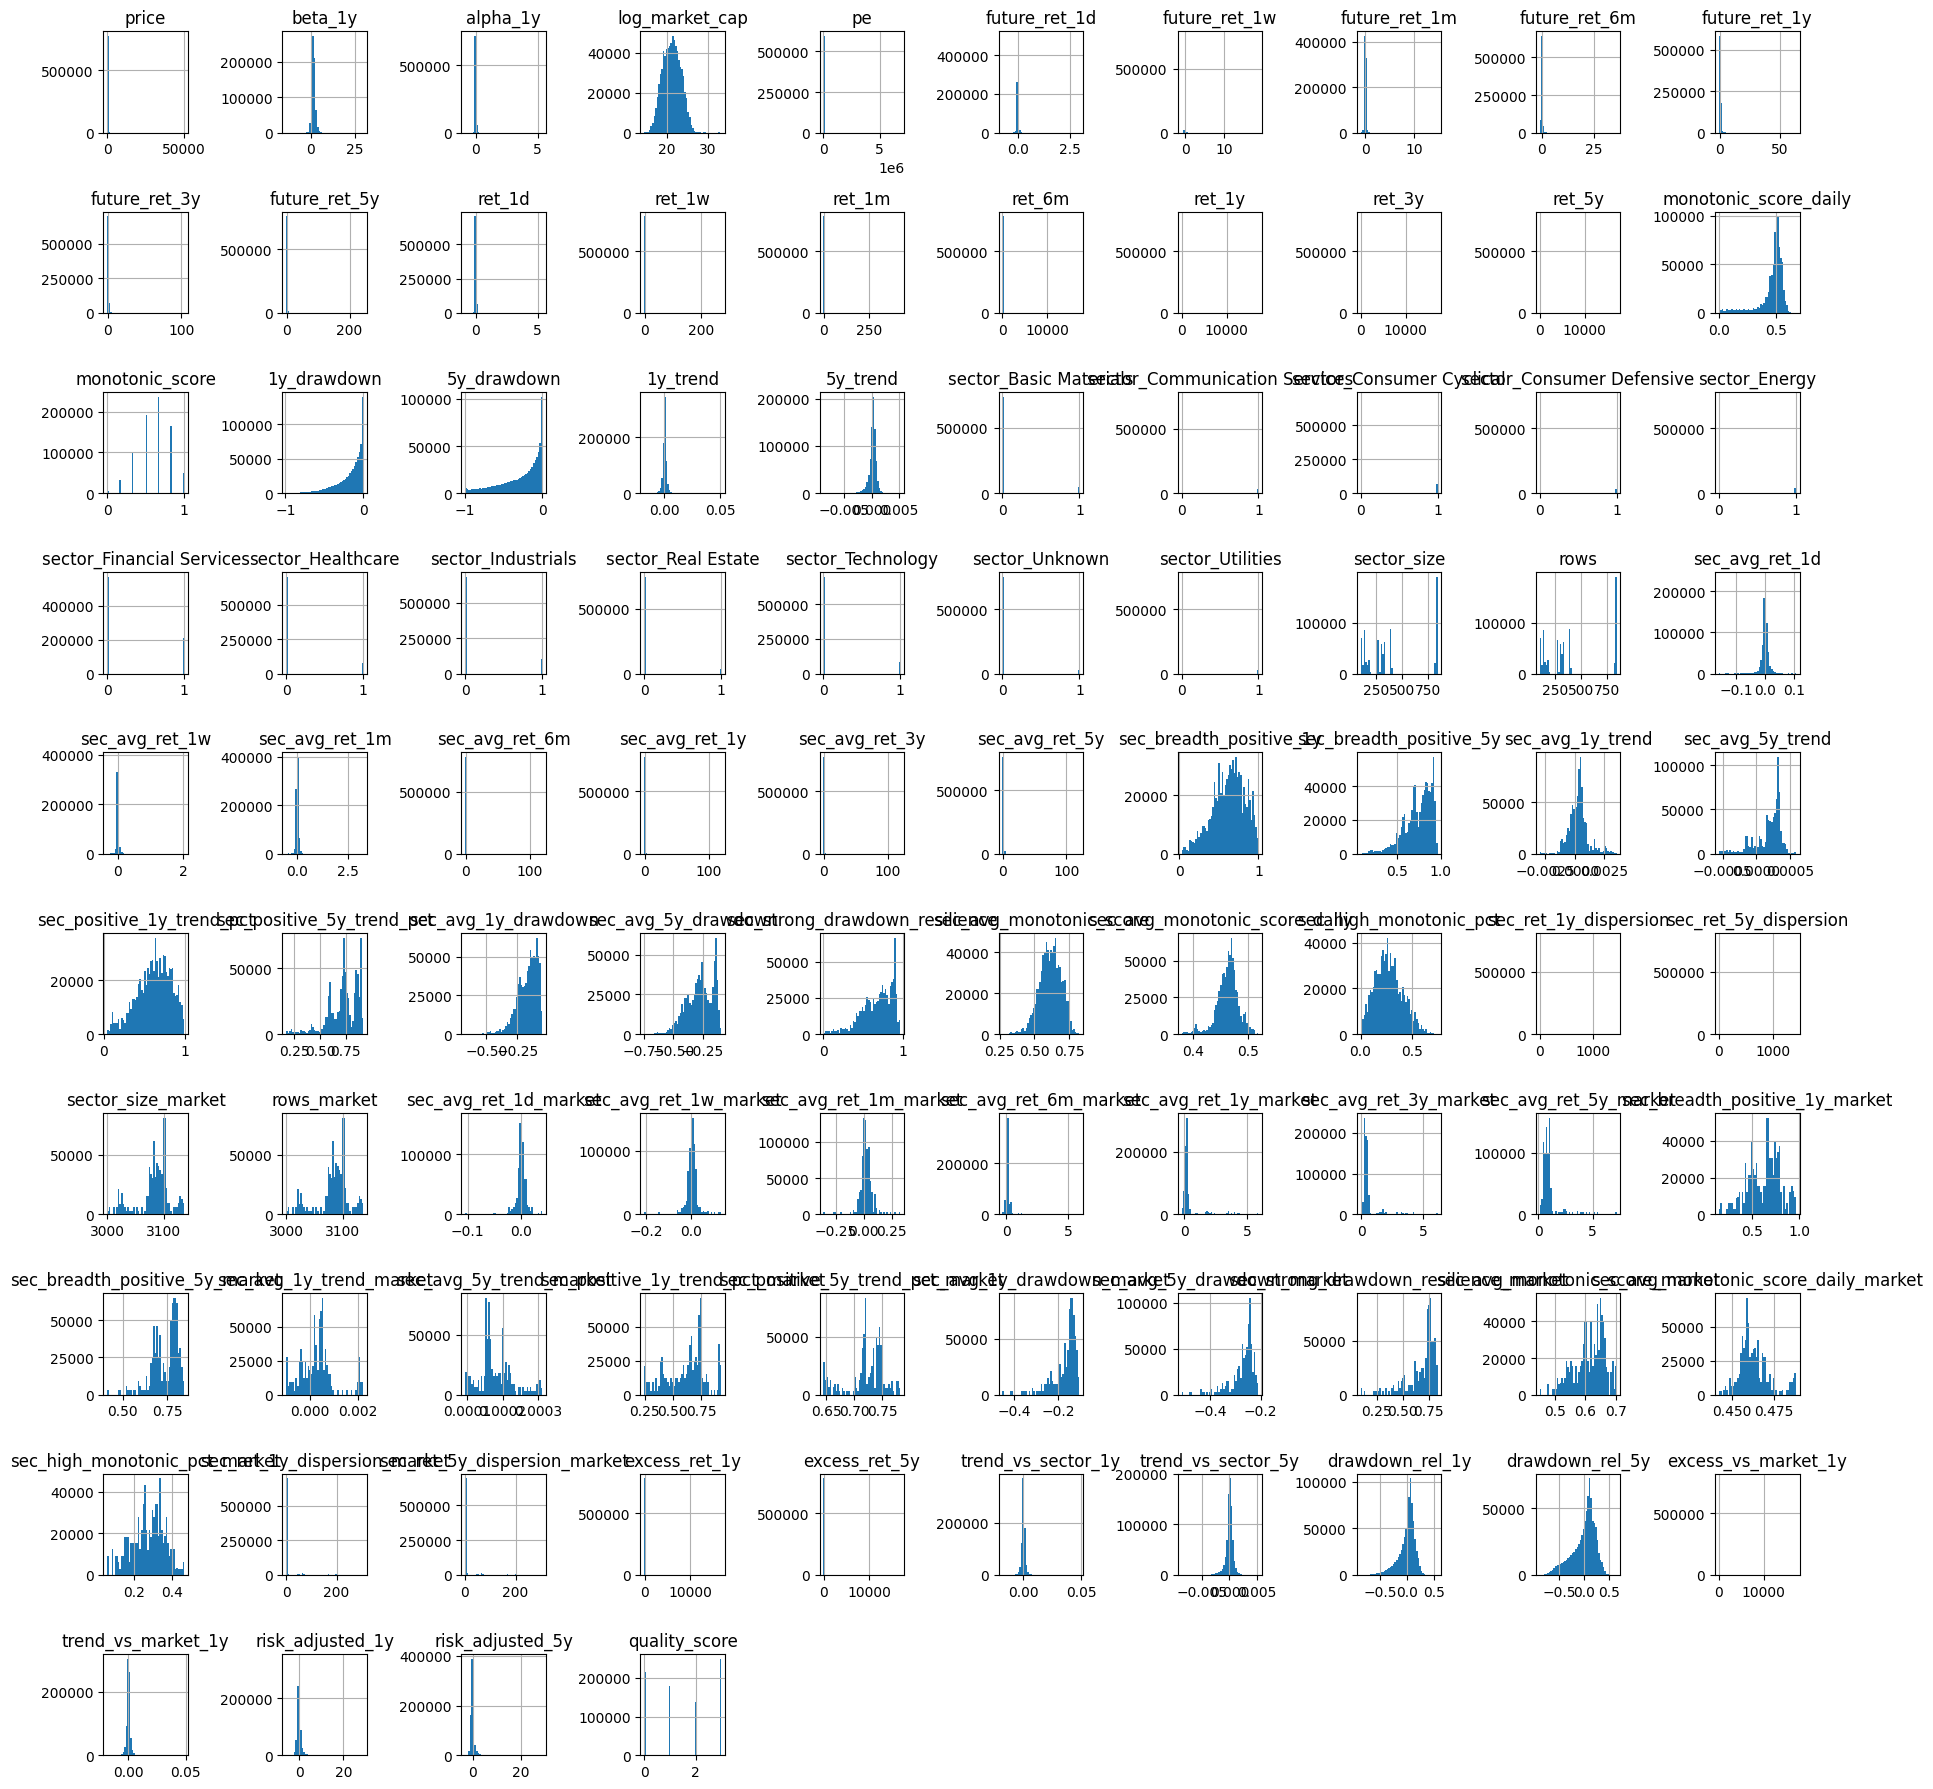

In [10]:
# Distribution Plot

import matplotlib.pyplot as plt

numeric.hist(figsize=(18, 18), bins=50)
plt.tight_layout()

In [11]:
future_cols = [c for c in df.columns if c.startswith("future_ret_")]

df[future_cols].describe().T

for col in future_cols:
    print(col)
    print(df[col].describe())
    print("Less than -100%:", (df[col] < -1).sum())
    print("Greater than 1000%:", (df[col] > 10).sum())
    print()

future_ret_1d
count    780126.000000
mean          0.001150
std           0.032566
min          -0.738594
25%          -0.008400
50%           0.000000
75%           0.009847
max           2.936410
Name: future_ret_1d, dtype: float64
Less than -100%: 0
Greater than 1000%: 0

future_ret_1w
count    780126.000000
mean          0.004004
std           0.077665
min          -0.895606
25%          -0.019665
50%           0.001178
75%           0.024287
max          18.728261
Name: future_ret_1w, dtype: float64
Less than -100%: 0
Greater than 1000%: 2

future_ret_1m
count    780126.000000
mean          0.015585
std           0.151224
min          -0.929595
25%          -0.038746
50%           0.009132
75%           0.059219
max          14.868853
Name: future_ret_1m, dtype: float64
Less than -100%: 0
Greater than 1000%: 3

future_ret_6m
count    780126.000000
mean          0.086375
std           0.425028
min          -0.974843
25%          -0.085695
50%           0.045468
75%           0.1879

In [12]:
future_cols = [c for c in df.columns if c.startswith("future_ret_")]

for col in future_cols:
    print("\n", col)

    extreme = df.nlargest(5, col)[
        ["ticker", "date", "price", col]
    ]

    print(extreme)


 future_ret_1d
       ticker       date  price  future_ret_1d
35197    AIRT 2020-12-23   9.75       2.936410
83059    UONE 2020-06-12  18.40       2.554348
131901   ASTC 2018-06-18  58.50       2.261539
137498   BPTH 2019-02-28  52.00       1.969231
774047    SLS 2020-12-09   6.39       1.763693

 future_ret_1w
       ticker       date  price  future_ret_1w
83059    UONE 2020-06-12  18.40      18.728261
137498   BPTH 2019-02-28  52.00      13.946154
484025   MMMW 2021-01-15   5.10       6.156863
385520   SCKT 2021-02-08   2.99       5.916388
428081    GBR 2018-06-25   1.34       5.641791

 future_ret_1m
       ticker       date      price  future_ret_1m
83056    UONE 2020-05-21  12.200000      14.868853
137496   BPTH 2019-02-13  41.400002      13.202898
83057    UONE 2020-05-29  13.100000      12.763359
484024   MMMW 2021-01-08   2.950000       9.677966
137495   BPTH 2019-02-06  41.599998       9.096154

 future_ret_6m
       ticker       date   price  future_ret_6m
509576    GME 2020